In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [2]:
import sys, torch
print(f"Python  : {sys.version}")
print(f"Torch   : {torch.__version__}")
print(f"Torch path : {torch.__file__}")

Python  : 3.14.3 | packaged by conda-forge | (main, Feb  9 2026, 21:56:02) [GCC 14.3.0]
Torch   : 2.11.0+cu130
Torch path : /shared/home/myoussef/.local/lib/python3.14/site-packages/torch/__init__.py


In [3]:
torch.cuda.is_available()

True

In [4]:
torch.cuda.get_device_name()

'NVIDIA H200 NVL'

In [5]:
torch.cuda.device_count()

1

In [6]:
print(torch.cuda.mem_get_info())  # (free, total)

(149557477376, 150109880320)


In [7]:
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/transformers
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/transformers-*.dist-info

#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/torch
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/torch-*.dist-info

#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/bacformer
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/bacformer-*.dist-info

In [8]:
#!/shared/software/miniconda/envs/python-3.11.2/bin/python -m pip install --no-cache-dir "transformers==4.57.5" bacformer

In [61]:
#!pip uninstall transformers -y

#!pip show transformers

#!pip install transformers==4.40.0 --break-system-packages

In [62]:
#!pip3 install transformers

In [64]:
#!pip3 install pandas
#!pip3 install biopython
#!pip3 install bacformer

In [9]:
import transformers, torch
print("transformers:", transformers.__version__)
print("transformers path:", transformers.__file__)
print("torch path:", torch.__file__)
from transformers import PreTrainedModel

transformers: 5.5.0
transformers path: /shared/home/myoussef/.local/lib/python3.14/site-packages/transformers/__init__.py
torch path: /shared/home/myoussef/.local/lib/python3.14/site-packages/torch/__init__.py


In [10]:
print(torch.__version__)
print(transformers.__version__)

2.11.0+cu130
5.5.0


In [11]:
import os, gzip
from pathlib import Path
from collections import Counter, defaultdict
import glob
import random

import numpy as np
import pandas as pd
from Bio import SeqIO

from transformers import AutoModel
from bacformer.pp import protein_seqs_to_bacformer_inputs
#from bacformer.modeling import SPECIAL_TOKENS_DICT

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_recall_curve)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [12]:
# bacformer/pp/preprocess.py
# chnagement de extract_protein_info_from_genbank() et preprocess_genome_assembly()

import gzip
from typing import Any

import pandas as pd
from Bio import SeqIO


def extract_protein_info_from_genbank(filepath: str):
    """
    Extract protein details from a GenBank file (.gbff/.gbk and optionally .gz) and return a DataFrame.

    Returns a DataFrame with columns used by Bacformer preprocessing.
    """
    if filepath.endswith(".gz"):
        handle = gzip.open(filepath, "rt")
    else:
        handle = open(filepath, "r")

    records = SeqIO.parse(handle, "genbank")
    data = []

    contig_idx = 0
    for record in records:
        genome_name = record.annotations.get("organism", None)

        for feature in record.features:
            if feature.type != "CDS":
                continue

            translation = feature.qualifiers.get("translation", [None])[0]
            if translation is None:
                continue

            gene_name = feature.qualifiers.get("gene", [None])[0]
            locus_tag = feature.qualifiers.get("locus_tag", [None])[0]
            protein_id = feature.qualifiers.get("protein_id", [None])[0]

            start = int(feature.location.start)
            end = int(feature.location.end)

            data.append(
                {
                    "strain_name": genome_name,
                    "gene_name": gene_name,
                    "protein_name": locus_tag,
                    "start": start,
                    "end": end,
                    "protein_id": protein_id,
                    "contig_idx": contig_idx,
                    "protein_sequence": translation,
                }
            )

        contig_idx += 1

    handle.close()
    return pd.DataFrame(data)

def extract_protein_info_from_gff(filepath):
    """
    Extract protein details from a GFF file (.gff or .gff.gz) into a pandas DataFrame.

    Args:
        filepath (str): Path to the GFF file.

    Returns
    -------
        pd.DataFrame: A DataFrame where each row is a gene, with columns for gene details.
    """
    genes = []

    # Open the file based on its extension
    if filepath.endswith(".gz"):
        open_func = gzip.open
        mode = "rt"  # Read as text
    else:
        open_func = open
        mode = "r"

    with open_func(filepath, mode) as file:
        for line in file:
            if line.startswith("#"):
                # # Extract assembly ID from the header
                # if line.startswith("##sequence-region"):
                #     assembly_id = line.split()[1]
                continue

            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue  # Skip malformed lines

            feature_type = parts[2]
            if feature_type != "CDS":
                continue  # Focus only on genes

            seqid = parts[0]
            start = int(parts[3])
            end = int(parts[4])
            strand = parts[6]
            attributes = parts[8]

            # Parse attributes
            attr_dict = {}
            for attr in attributes.split(";"):
                if "=" in attr:
                    key, value = attr.split("=", 1)
                    attr_dict[key] = value

            # Extract specific fields
            gene_name = attr_dict.get("gene", None)
            locus_tag = attr_dict.get("locus_tag", None)
            protein_id = attr_dict.get("protein_id", None)

            # Append gene info to the list
            genes.append(
                {
                    "seqid": seqid,
                    "start": start,
                    "end": end,
                    "strand": strand,
                    "gene_name": gene_name if gene_name is not None else locus_tag,
                    "locus_tag": locus_tag,
                    "protein_id": protein_id,
                }
            )

    # Convert to DataFrame
    df = pd.DataFrame(genes)
    return df

def preprocess_genome_assembly(filepath: str) -> dict[str, Any]:
    """
    Preprocess a genome assembly file (GenBank or GFF) to extract protein information for Bacformer input.
    Modified: does NOT rely on accession fields; accepts .gbk/.gbk.gz too.
    """
    if filepath.endswith((".gbff", ".gbff.gz", ".gbk", ".gbk.gz")):
        df = extract_protein_info_from_genbank(filepath)
    elif filepath.endswith((".gff", ".gff.gz")):
        df = extract_protein_info_from_gff(filepath)
    else:
        raise ValueError("Unsupported file format. Use .gbff/.gbk or .gff (optionally .gz).")

    if df.empty:
        raise ValueError("No protein translations found in file (empty CDS/translation set).")

    # groupby contig and aggregate protein information
    df = (
        df.groupby(["strain_name", "contig_idx"])[
            ["gene_name", "protein_name", "start", "end", "protein_id", "protein_sequence"]
        ]
        .agg(list)
        .reset_index()
    )

    # sort by contig_idx
    df = df.sort_values(by="contig_idx", ascending=True)

    # aggregate all contigs in the genome
    df = (
        df.groupby(["strain_name"])[
            ["contig_idx", "gene_name", "protein_name", "start", "end", "protein_id", "protein_sequence"]
        ]
        .agg(list)
        .reset_index()
    )

    return dict(df.iloc[0])

In [42]:
INPUT_DIR = "genomes_gbff"
OUT_DIR = "embeddings_out"
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda:0" #if torch.cuda.is_available() else "cpu"

# Charger le modèle une fois
model = AutoModel.from_pretrained(
    "macwiatrak/bacformer-masked-complete-genomes", trust_remote_code=True
).to(device).eval().to(torch.bfloat16)

# vérifier que le .pt existe et est OK 
def output_is_valid(out_path: str) -> bool:
    if not os.path.isfile(out_path):
        return False
    try:
        obj = torch.load(out_path)
        # présence et type/shape
        if "last_hidden_state" not in obj:
            return False
        t = obj["last_hidden_state"]
        if not torch.is_tensor(t):
            return False
        if t.ndim != 3:
            return False
        return True
    except Exception:
        return False

# Boucle sur les fichiers gbff
files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.gbff")))
print("Nb fichiers:", len(files))

for fp in files:
    genome_id = os.path.splitext(os.path.basename(fp))[0]
    
    # vérifier si déjà généré
    out_path = os.path.join(OUT_DIR, f"{genome_id}.pt")
    if output_is_valid(out_path):
        print("Skipping (already done):", genome_id)
        continue
    
    print("Processing:", genome_id)

    genome_info = preprocess_genome_assembly(filepath=fp)
    protein_seqs = genome_info["protein_sequence"]

    inputs = protein_seqs_to_bacformer_inputs(
        protein_seqs,
        device=device,
        batch_size=128,
        max_n_proteins=6000,
    )

    # 3) Bacformer: embeddings contextualisés
    with torch.no_grad():
        outputs = model(**inputs, return_dict=True)

    last_hidden = outputs["last_hidden_state"]  # (1, seq_len, dim)
    # Pour un "genome embedding" par moyenne de seq_len
    #genome_emb = last_hidden.mean(dim=1)

    # 4) Sauvegarde simple
    #out_path = os.path.join(OUT_DIR, f"{genome_id}.pt")
    torch.save(
        {
            "genome_id": genome_id,
            "n_proteins": len(protein_seqs),
            "last_hidden_state": last_hidden.cpu(),  # embeddings contextualisés
            #"genome_embedding_mean": genome_emb.cpu(),
        },
        out_path,
    )

    print("  saved:", out_path, "| last_hidden_state:", tuple(last_hidden.shape))

Loading weights:   0%|          | 0/162 [00:00<?, ?it/s]

BacformerModel LOAD REPORT from: macwiatrak/bacformer-masked-complete-genomes
Key                       | Status     |  | 
--------------------------+------------+--+-
gm_head.layer_norm.bias   | UNEXPECTED |  | 
gm_head.bias              | UNEXPECTED |  | 
gm_head.dense.bias        | UNEXPECTED |  | 
gm_head.layer_norm.weight | UNEXPECTED |  | 
gm_head.decoder.weight    | UNEXPECTED |  | 
gm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Nb fichiers: 1066
Skipping (already done): 1328432.3
Skipping (already done): 1328433.3
Skipping (already done): 1328434.3
Skipping (already done): 1328436.3
Skipping (already done): 1328437.3
Skipping (already done): 1328438.3
Skipping (already done): 1328439.3
Skipping (already done): 1328440.3
Skipping (already done): 1328441.3
Skipping (already done): 1328442.3
Skipping (already done): 1328443.3
Skipping (already done): 1328444.3
Skipping (already done): 1328445.3
Skipping (already done): 1328446.3
Skipping (already done): 1328447.3
Skipping (already done): 1328448.3
Skipping (already done): 1328449.3
Skipping (already done): 1328450.3
Skipping (already done): 1400156.3
Skipping (already done): 1400157.3
Skipping (already done): 1400158.3
Skipping (already done): 1416670.3
Skipping (already done): 1416671.3
Skipping (already done): 1416672.3
Skipping (already done): 1416673.3
Skipping (already done): 1416674.4
Skipping (already done): 1416675.3
Skipping (already done): 1438668.3
Sk

In [13]:
x = torch.load("./embeddings_out/562.90695.pt")["last_hidden_state"]
print(x[0, :7, :7])  # 7 protéines/tokens × 7 dimensions

tensor([[ 0.1187,  0.2168, -0.1099,  0.1641, -0.1216,  0.0041, -0.4629],
        [-0.0398,  0.3574,  0.1108,  0.2812, -0.0366,  0.2119, -0.3711],
        [ 0.0820,  0.2080,  0.0184,  0.3359, -0.3223, -0.1348, -0.3984],
        [-0.1787,  0.1357,  0.1641,  0.3691, -0.2559,  0.0439, -0.0371],
        [-0.0199,  0.1318, -0.0327,  0.1455, -0.1025,  0.4668, -0.2773],
        [ 0.1914,  0.2812, -0.4375, -0.0884,  0.0767,  0.4609, -0.2012],
        [ 0.2363,  0.0918, -0.2354, -0.0442,  0.2256,  0.1846, -0.0081]],
       dtype=torch.bfloat16)


In [70]:
#Si val AUC/F1 baisse alors que train loss baisse → overfit → dropout↑ ou hidden↓
#si tu overfit (train monte, val baisse) → baisse à 64
#si tu sous-apprends (train et val mauvais) → monte à 256

In [14]:
PT_DIR      = "embeddings_out"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"
 
SEED       = 42
BATCH_SIZE = 8
EPOCHS     = 50
LR         = 3e-4
ATTN_DIM   = 128
HIDDEN     = 128
DROPOUT    = 0.3
 
device = "cuda" if torch.cuda.is_available() else "cpu"
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
set_seed(SEED)
print(f"Seed fixée à {SEED} | device : {device}")

Seed fixée à 42 | device : cuda


In [15]:
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: shape inattendue {tuple(X.shape)}")
    return gid, X.float()

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())

    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))

id_to_y = load_labels(LABELS_PATH)

# Charger tous les fichiers
all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]
n_proteins_list = []

print(f"\n Fichiers .pt trouvés   : {len(all_files)}")
print(f"   Avec label matching   : {len(matched)}")
print(f"   Sans label (ignorés)  : {len(all_files) - len(matched)}")

# Résistants / Sensibles parmi les labellisés
matched_labels  = np.array([id_to_y[load_pt(fp)[0]] for fp in matched])
n_resistant     = int(matched_labels.sum())
n_susceptible   = int(len(matched_labels) - n_resistant)
ratio           = matched_labels.mean()

print(f"\n Parmi les {len(matched)} génomes labellisés :")
print(f"   Résistants  (1) : {n_resistant}  ({ratio:.1%})")
print(f"   Sensibles   (0) : {n_susceptible}  ({1-ratio:.1%})")
if ratio < 0.10:
    print("    Déséquilibre SÉVÈRE")
elif ratio < 0.20:
    print("    Déséquilibre MODÉRÉ")
else:
    print("    Distribution acceptable")

# Stats sur la taille des génomes (nombre de protéines)
for fp in matched[:50]:
    _, X = load_pt(fp)
    n_proteins_list.append(X.shape[0])

print(f"\n Taille des génomes (nb protéines) sur 50 échantillons :")
print(f"   Min    : {np.min(n_proteins_list)}")
print(f"   Max    : {np.max(n_proteins_list)}")
print(f"   Moyenne: {np.mean(n_proteins_list):.0f}")
print(f"   Médiane: {np.median(n_proteins_list):.0f}")
print(f"\n     Dimension embedding (D) : {load_pt(matched[0])[1].shape[1]}")


 Fichiers .pt trouvés   : 1066
   Avec label matching   : 907
   Sans label (ignorés)  : 159

 Parmi les 907 génomes labellisés :
   Résistants  (1) : 53  (5.8%)
   Sensibles   (0) : 854  (94.2%)
    Déséquilibre SÉVÈRE

 Taille des génomes (nb protéines) sur 50 échantillons :
   Min    : 4426
   Max    : 5358
   Moyenne: 4935
   Médiane: 4973

     Dimension embedding (D) : 480


In [16]:
class GenomeMILDataset(Dataset):
    def __init__(self, pt_dir, id_to_y):
        self.id_to_y = id_to_y
        files = sorted(glob.glob(os.path.join(pt_dir, "*.pt")))
        self.files = [fp for fp in files if load_pt(fp)[0] in id_to_y]
        if len(self.files) == 0:
            raise ValueError("Aucun .pt matché avec les labels.")
 
    def __len__(self):
        return len(self.files)
 
    def __getitem__(self, idx):
        gid, X = load_pt(self.files[idx])
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid
    
def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    D    = xs[0].shape[1]
    Pmax = max(x.shape[0] for x in xs)
    Xpad = torch.zeros((len(xs), Pmax, D))
    mask = torch.zeros((len(xs), Pmax))
    for i, x in enumerate(xs):
        Xpad[i, :x.shape[0]] = x
        mask[i, :x.shape[0]] = 1.0
    return Xpad, mask, torch.stack(list(ys)), list(gids)
 
dataset = GenomeMILDataset(PT_DIR, id_to_y)
n = len(dataset)
 
# Labels dans l'ordre du dataset
all_labels = np.array([id_to_y[load_pt(dataset.files[i])[0]] for i in range(n)])
 
# Stratified split
train_val_idx, test_idx = train_test_split(
    np.arange(n), test_size=0.1, stratify=all_labels, random_state=SEED
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.1/0.9,
    stratify=all_labels[train_val_idx], random_state=SEED
)
 
train_ds = Subset(dataset, train_idx)
val_ds   = Subset(dataset, val_idx)
test_ds  = Subset(dataset, test_idx)
 
# Oversampling sur le train
train_labels  = all_labels[train_idx]
class_counts  = np.bincount(train_labels)
sample_weights = 1.0 / class_counts[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(train_labels),
    replacement=True
)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=mil_collate)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   collate_fn=mil_collate)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   collate_fn=mil_collate)
 
# Diagnostic split
def split_stats(name, indices, labels):
    l = labels[indices]
    print(f"   {name:6s} : {len(l):4d} génomes | résistants {l.sum():3.0f} ({l.mean():.1%}) | sensibles {len(l)-l.sum():3.0f}")
 
print(f"Split STRATIFIÉ (même ratio dans chaque split) :")
split_stats("Train", train_idx, all_labels)
split_stats("Val",   val_idx,   all_labels)
split_stats("Test",  test_idx,  all_labels)
print(f"\n Oversampling activé sur le train")
print(f"   → Les résistants seront sur-échantillonnés pour équilibrer les batches")
 

Split STRATIFIÉ (même ratio dans chaque split) :
   Train  :  725 génomes | résistants  43 (5.9%) | sensibles 682
   Val    :   91 génomes | résistants   5 (5.5%) | sensibles  86
   Test   :   91 génomes | résistants   5 (5.5%) | sensibles  86

 Oversampling activé sur le train
   → Les résistants seront sur-échantillonnés pour équilibrer les batches


In [17]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
 
    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()
    
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False
        self.best_state = None
 
    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                
class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.3):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        
        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)
        
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            #nn.Linear(hidden, hidden // 2),
            #nn.ReLU(),
            #nn.Linear(hidden // 2, 1),
            nn.Linear(hidden, 1),
        )
 
    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)
        
        # ignore padding for softmax
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)
        
        z     = torch.sum(X * alpha.unsqueeze(-1), dim=1)
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha

X0, _, _ = dataset[0]
emb_dim  = X0.shape[1]
model    = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)
 
criterion      = FocalLoss(alpha=0.75, gamma=2.0)
optimizer      = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler      = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)
 
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Modèle initialisé")
print(f"   emb_dim       : {emb_dim}")
print(f"   Nb paramètres : {n_params:,}")
print(f"   Loss          : FocalLoss (alpha=0.75, gamma=2.0)")
print(f"   Optimiseur    : AdamW (lr={LR}, wd=1e-2)")
 

 Modèle initialisé
   emb_dim       : 480
   Nb paramètres : 185,218
   Loss          : FocalLoss (alpha=0.75, gamma=2.0)
   Optimiseur    : AdamW (lr=0.0003, wd=1e-2)


In [18]:
def find_best_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s      = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1s)
    return float(thresholds[best_idx])
 
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    auc    = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    return {"acc": acc, "f1": f1, "auc": auc}
 
@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_y, all_prob = [], []
    for Xpad, mask, y, _ in loader:
        logits, _ = model(Xpad.to(device), mask.to(device))
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_prob)
 
@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval()
    all_y, all_prob, total_loss, n_batches = [], [], 0.0, 0
    for Xpad, mask, y, _ in loader:
        Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
        logits, _     = model(Xpad, mask)
        total_loss   += float(criterion(logits, y).item())
        all_prob.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy())
        n_batches += 1
    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_prob)
    m      = compute_metrics(y_true, y_prob, threshold)
    m["loss"] = total_loss / max(n_batches, 1)
    return m
 
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, n_batches = 0.0, 0
    for Xpad, mask, y, _ in loader:
        Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        logits, _ = model(Xpad, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item())
        n_batches  += 1
    return total_loss / max(n_batches, 1)

In [19]:
# Avec Cross-validation stratifiée 5-fold

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_results = []

print(f"Cross-validation 5-fold stratifiée")
print(f"   Total génomes : {n} | Résistants : {all_labels.sum()} ({all_labels.mean():.1%})\n")
print(f"{'Fold':>4} | {'val_auc':>7} {'val_f1':>6} | {'te_auc':>7} {'te_f1':>6} {'te_acc':>6} | {'seuil':>5} | {'te_f1_opt':>9}")
print("-" * 75)

for fold, (train_val_idx, test_idx) in enumerate(skf.split(np.arange(n), all_labels), 1):
    
    fold_history = {
        "train_loss": [],
        "val_auc":    [],
        "val_f1":     [],
        "test_auc":   [],
        "test_f1":    [],
    }

    # Split train / val / test
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=0.1/0.9,
        stratify=all_labels[train_val_idx], random_state=SEED
    )

    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)
    test_ds  = Subset(dataset, test_idx)

    # Oversampling sur le train
    train_labels   = all_labels[train_idx]
    class_counts   = np.bincount(train_labels)
    sample_weights = 1.0 / class_counts[train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float),
        num_samples=len(train_labels),
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,   collate_fn=mil_collate)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,     collate_fn=mil_collate)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,     collate_fn=mil_collate)

    # Nouveau modèle pour chaque fold
    fold_model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)
    fold_criterion    = FocalLoss(alpha=0.85, gamma=2.0)
    fold_optimizer    = optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-2)
    fold_scheduler    = optim.lr_scheduler.ReduceLROnPlateau(fold_optimizer, mode="max", factor=0.5, patience=2)
    fold_early_stop   = EarlyStopping(patience=5, min_delta=0.001)

    # Entraînement
    for epoch in range(1, EPOCHS + 1):
        # train
        fold_model.train()
        epoch_loss = 0.0     
        n_batches  = 0 
        for Xpad, mask, y, _ in train_loader:
            Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
            fold_optimizer.zero_grad()
            logits, _ = fold_model(Xpad, mask)
            loss = fold_criterion(logits, y)
            loss.backward()
            fold_optimizer.step()
            epoch_loss += loss.item()  
            n_batches  += 1 
                
        train_loss = epoch_loss / max(n_batches, 1)

        # val
        val_m  = evaluate(fold_model, val_loader)
        test_m = evaluate(fold_model, test_loader)
        
        
        fold_history["train_loss"].append(epoch_loss / max(n_batches, 1))  
        fold_history["val_auc"].append(val_m["auc"]   or 0)                
        fold_history["val_f1"].append(val_m["f1"]    or 0)                 
        fold_history["test_auc"].append(test_m["auc"]  or 0)               
        fold_history["test_f1"].append(test_m["f1"]   or 0)     
            
        score  = 0.5 * (val_m["auc"] or 0) + 0.5 * (val_m["f1"] or 0)
        fold_scheduler.step(score)
        fold_early_stop(score, fold_model)

        if fold_early_stop.stop:
            break

    # Restore best + évaluation finale
    if fold_early_stop.best_state:
        fold_model.load_state_dict(fold_early_stop.best_state)

    val_y,  val_prob  = get_probs(fold_model, val_loader)
    test_y, test_prob = get_probs(fold_model, test_loader)

    best_thr  = find_best_threshold(val_y, val_prob)
    val_m     = compute_metrics(val_y,  val_prob, threshold=0.5)
    test_def  = compute_metrics(test_y, test_prob, threshold=0.5)
    test_opt  = compute_metrics(test_y, test_prob, threshold=best_thr)

    print(
        f"{fold:>4} | {val_m['auc'] or 0:>7.3f} {val_m['f1']:>6.3f} | "
        f"{test_def['auc'] or 0:>7.3f} {test_def['f1']:>6.3f} {test_def['acc']:>6.3f} | "
        f"{best_thr:>5.2f} | {test_opt['f1']:>9.3f}"
    )

    fold_results.append({
        "fold":        fold,
        "val_auc":     val_m["auc"]     or 0,
        "val_f1":      val_m["f1"],
        "test_auc":    test_def["auc"]  or 0,
        "test_f1":     test_def["f1"],
        "test_f1_opt": test_opt["f1"],
        "threshold":   best_thr,
        "n_test":      len(test_y),
        "n_resistant_test": int(test_y.sum()),
        "history":     fold_history,
    })

# Résumé final
print("-" * 75)
metrics = ["val_auc", "val_f1", "test_auc", "test_f1", "test_f1_opt"]
print(f"\n Résumé sur 5 folds :")
for m in metrics:
    vals = [r[m] for r in fold_results]
    print(f"   {m:>12} : {np.mean(vals):.3f} ± {np.std(vals):.3f}")

print(f"\n   Résistants par fold test : {[r['n_resistant_test'] for r in fold_results]}")
print(f"   Seuils optimaux          : {[round(r['threshold'],2) for r in fold_results]}")

Cross-validation 5-fold stratifiée
   Total génomes : 907 | Résistants : 53 (5.8%)

Fold | val_auc val_f1 |  te_auc  te_f1 te_acc | seuil | te_f1_opt
---------------------------------------------------------------------------
   1 |   1.000  0.833 |   0.903  0.571  0.951 |  0.57 |     0.400
   2 |   0.889  0.615 |   0.858  0.483  0.918 |  0.64 |     0.600
   3 |   0.995  0.909 |   0.967  0.533  0.961 |  0.52 |     0.462
   4 |   0.942  0.588 |   0.924  0.600  0.956 |  0.54 |     0.429
   5 |   0.947  0.800 |   0.928  0.700  0.967 |  0.65 |     0.737
---------------------------------------------------------------------------

 Résumé sur 5 folds :
        val_auc : 0.955 ± 0.040
         val_f1 : 0.749 ± 0.126
       test_auc : 0.916 ± 0.036
        test_f1 : 0.578 ± 0.073
    test_f1_opt : 0.525 ± 0.126

   Résistants par fold test : [11, 11, 10, 10, 11]
   Seuils optimaux          : [0.57, 0.64, 0.52, 0.54, 0.65]


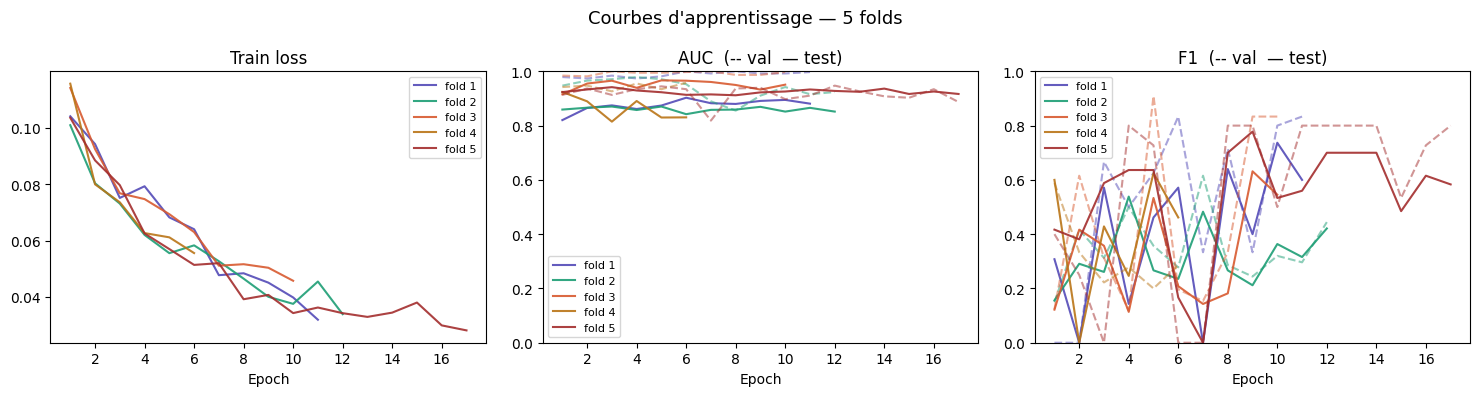


 Meilleurs scores moyens sur 5 folds :
   Val  F1  : 0.749  |  Test F1  : 0.662
   Val  AUC : 0.977  |  Test AUC : 0.921

    Performances correctes !


In [20]:
colors = ["#534AB7", "#1D9E75", "#D85A30", "#BA7517", "#A32D2D"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Courbes d'apprentissage — 5 folds", fontsize=13)

for r in fold_results:
    h  = r["history"]
    ep = np.arange(1, len(h["train_loss"]) + 1)
    c  = colors[r["fold"] - 1]
    lb = f"fold {r['fold']}"

    axes[0].plot(ep, h["train_loss"], color=c, linestyle="-",  alpha=0.9, label=lb)
    axes[1].plot(ep, h["val_auc"],   color=c, linestyle="--", alpha=0.5)
    axes[1].plot(ep, h["test_auc"],  color=c, linestyle="-",  alpha=0.9, label=lb)
    axes[2].plot(ep, h["val_f1"],    color=c, linestyle="--", alpha=0.5)
    axes[2].plot(ep, h["test_f1"],   color=c, linestyle="-",  alpha=0.9, label=lb)

axes[0].set_title("Train loss")
axes[0].set_xlabel("Epoch")
axes[1].set_title("AUC  (-- val  — test)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[2].set_title("F1  (-- val  — test)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()

# Diagnostic
best_val_auc  = np.mean([max(r["history"]["val_auc"])  for r in fold_results])
best_test_auc = np.mean([max(r["history"]["test_auc"]) for r in fold_results])
best_val_f1   = np.mean([max(r["history"]["val_f1"])   for r in fold_results])
best_test_f1  = np.mean([max(r["history"]["test_f1"])  for r in fold_results])

print(f"\n Meilleurs scores moyens sur 5 folds :")
print(f"   Val  F1  : {best_val_f1:.3f}  |  Test F1  : {best_test_f1:.3f}")
print(f"   Val  AUC : {best_val_auc:.3f}  |  Test AUC : {best_test_auc:.3f}")

gap_auc = best_val_auc - best_test_auc
if gap_auc > 0.10:
    print(f"\n    Écart val/test AUC = {gap_auc:.3f} → possible overfitting sur la val")
elif best_test_f1 < 0.4:
    print(f"\n    F1 test encore bas : déséquilibre ou manque de données résistants")
else:
    print(f"\n    Performances correctes !")

In [21]:
# Comparaison des 3 loss functions (cross-val 5-fold)

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Définition des 3 options
def get_criterion(option, train_labels, device):
    n_pos = float(train_labels.sum())
    n_neg = float(len(train_labels) - n_pos)
    pw    = n_neg / max(n_pos, 1.0)

    if option == "A":
        return FocalLoss(alpha=0.85, gamma=2.0)
    elif option == "B":
        return nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pw], dtype=torch.float32, device=device)
        )
    elif option == "C":
        class FocalLossWeighted(nn.Module):
            def __init__(self, alpha, gamma, pw):
                super().__init__()
                self.alpha = alpha
                self.gamma = gamma
                self.pw    = pw
            def forward(self, logits, targets):
                bce  = F.binary_cross_entropy_with_logits(
                    logits, targets,
                    pos_weight=torch.tensor([self.pw], device=logits.device),
                    reduction='none'
                )
                pt   = torch.exp(-bce)
                loss = self.alpha * (1 - pt) ** self.gamma * bce
                return loss.mean()
        return FocalLossWeighted(alpha=0.85, gamma=2.0, pw=pw)

# Boucle sur les 3 options
all_results = {}

for option in ["A", "B", "C"]:
    print(f"\n{'='*65}")
    print(f"  Option {option} : {'FocalLoss(alpha=0.85, gamma=2.0)' if option=='A' else 'BCEWithLogitsLoss(pos_weight)' if option=='B' else 'FocalLoss + pos_weight combinés'}")
    print(f"{'='*65}")
    print(f"{'Fold':>4} | {'val_auc':>7} {'val_f1':>6} | {'te_auc':>7} {'te_f1':>6} | {'seuil':>5} | {'te_f1_opt':>9}")
    print("-" * 65)

    fold_results = []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(np.arange(n), all_labels), 1):

        # Split
        train_idx, val_idx = train_test_split(
            train_val_idx, test_size=0.1/0.9,
            stratify=all_labels[train_val_idx], random_state=SEED
        )

        train_ds = Subset(dataset, train_idx)
        val_ds   = Subset(dataset, val_idx)
        test_ds  = Subset(dataset, test_idx)

        # Oversampling
        train_labels   = all_labels[train_idx]
        class_counts   = np.bincount(train_labels)
        sample_weights = 1.0 / class_counts[train_labels]
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(train_labels),
            replacement=True
        )

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=mil_collate)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   collate_fn=mil_collate)
        test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   collate_fn=mil_collate)

        # Modèle + criterion 
        fold_model     = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)
        fold_criterion = get_criterion(option, train_labels, device)
        fold_optimizer = optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-2)
        fold_scheduler = optim.lr_scheduler.ReduceLROnPlateau(fold_optimizer, mode="max", factor=0.5, patience=2)
        fold_early_stop= EarlyStopping(patience=5, min_delta=0.001)

        # Entraînement 
        for epoch in range(1, EPOCHS + 1):
            fold_model.train()
            for Xpad, mask, y, _ in train_loader:
                Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
                fold_optimizer.zero_grad()
                logits, _ = fold_model(Xpad, mask)
                loss = fold_criterion(logits, y)
                loss.backward()
                fold_optimizer.step()

            val_m = evaluate(fold_model, val_loader)
            score = 0.5 * (val_m["auc"] or 0) + 0.5 * (val_m["f1"] or 0)
            fold_scheduler.step(score)
            fold_early_stop(score, fold_model)
            if fold_early_stop.stop:
                break

        # Évaluation
        if fold_early_stop.best_state:
            fold_model.load_state_dict(fold_early_stop.best_state)

        val_y,  val_prob  = get_probs(fold_model, val_loader)
        test_y, test_prob = get_probs(fold_model, test_loader)

        best_thr = find_best_threshold(val_y, val_prob)
        val_m    = compute_metrics(val_y,  val_prob, threshold=0.5)
        test_def = compute_metrics(test_y, test_prob, threshold=0.5)
        test_opt = compute_metrics(test_y, test_prob, threshold=best_thr)

        print(
            f"{fold:>4} | {val_m['auc'] or 0:>7.3f} {val_m['f1']:>6.3f} | "
            f"{test_def['auc'] or 0:>7.3f} {test_def['f1']:>6.3f} | "
            f"{best_thr:>5.2f} | {test_opt['f1']:>9.3f}"
        )

        fold_results.append({
            "val_auc":     val_m["auc"]    or 0,
            "val_f1":      val_m["f1"],
            "test_auc":    test_def["auc"] or 0,
            "test_f1":     test_def["f1"],
            "test_f1_opt": test_opt["f1"],
        })

    # Résumé par option
    print("-" * 65)
    for m in ["val_auc", "val_f1", "test_auc", "test_f1", "test_f1_opt"]:
        vals = [r[m] for r in fold_results]
        print(f"   {m:>12} : {np.mean(vals):.3f} ± {np.std(vals):.3f}")

    all_results[option] = fold_results

# Comparaison finale des 3 options
print(f"\n{'='*65}")
print(f"  COMPARAISON FINALE — test_f1_opt (seuil optimal)")
print(f"{'='*65}")
print(f"{'Option':>8} | {'test_f1_opt':>11} | {'test_auc':>8} | {'val_f1':>6}")
print("-" * 45)
for option in ["A", "B", "C"]:
    r   = all_results[option]
    f1  = np.mean([x["test_f1_opt"] for x in r])
    auc = np.mean([x["test_auc"]    for x in r])
    vf1 = np.mean([x["val_f1"]      for x in r])
    print(f"{'Option '+option:>8} | {f1:>11.3f} | {auc:>8.3f} | {vf1:>6.3f}")

best_option = max(["A","B","C"], key=lambda o: np.mean([x["test_f1_opt"] for x in all_results[o]]))
print(f"\n  Meilleure option : {best_option}")


  Option A : FocalLoss(alpha=0.85, gamma=2.0)
Fold | val_auc val_f1 |  te_auc  te_f1 | seuil | te_f1_opt
-----------------------------------------------------------------
   1 |   0.987  0.800 |   0.882  0.500 |  0.53 |     0.400
   2 |   0.953  0.421 |   0.866  0.364 |  0.84 |     0.545
   3 |   0.987  0.833 |   0.962  0.471 |  0.52 |     0.533
   4 |   0.974  0.667 |   0.933  0.500 |  0.53 |     0.429
   5 |   0.913  0.800 |   0.921  0.667 |  0.60 |     0.737
-----------------------------------------------------------------
        val_auc : 0.963 ± 0.028
         val_f1 : 0.704 ± 0.153
       test_auc : 0.913 ± 0.035
        test_f1 : 0.500 ± 0.097
    test_f1_opt : 0.529 ± 0.119

  Option B : BCEWithLogitsLoss(pos_weight)
Fold | val_auc val_f1 |  te_auc  te_f1 | seuil | te_f1_opt
-----------------------------------------------------------------
   1 |   0.995  0.417 |   0.859  0.410 |  0.99 |     0.471
   2 |   0.963  0.526 |   0.883  0.364 |  0.98 |     0.609
   3 |   0.968  0.35

In [22]:
#sans cross-val :

history = {k: [] for k in ["train_loss", "val_loss", "val_auc", "val_f1", "test_auc", "test_f1"]}
 
print(f" Début entraînement ({EPOCHS} époques max, early stopping patience=7)\n")
print(f"{'Epoch':>5} | {'tr_loss':>8} | {'val_loss':>8} {'val_acc':>7} {'val_f1':>6} {'val_auc':>7} | {'te_acc':>6} {'te_f1':>6} {'te_auc':>7}")
print("-" * 80)
 
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer)
    val_m   = evaluate(model, val_loader)
    test_m  = evaluate(model, test_loader)
 
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_m["loss"])
    history["val_auc"].append(val_m["auc"])
    history["val_f1"].append(val_m["f1"])
    history["test_auc"].append(test_m["auc"])
    history["test_f1"].append(test_m["f1"])
 
    score = val_m["auc"] if val_m["auc"] is not None else (val_m["f1"] or -1.0)
    scheduler.step(score)
    early_stopping(score, model)
 
    print(
        f"{epoch:5d} | {tr_loss:8.4f} | "
        f"{val_m['loss']:8.4f} {val_m['acc']:7.3f} {val_m['f1']:6.3f} {val_m['auc'] or 0:7.3f} | "
        f"{test_m['acc']:6.3f} {test_m['f1']:6.3f} {test_m['auc'] or 0:7.3f}"
    )
 
    if early_stopping.stop:
        print(f"\n  Early stopping à l'époque {epoch} (patience={early_stopping.patience})")
        break

if early_stopping.best_state:
    model.load_state_dict(early_stopping.best_state)
    print(f" Meilleur modèle restauré (val_auc = {early_stopping.best_score:.4f})")

 Début entraînement (50 époques max, early stopping patience=7)

Epoch |  tr_loss | val_loss val_acc val_f1 val_auc | te_acc  te_f1  te_auc
--------------------------------------------------------------------------------
    1 |   0.0886 |   0.1308   0.642  0.256   0.961 |  0.691  0.282   0.941
    2 |   0.0742 |   0.0388   0.938  0.615   0.950 |  0.934  0.538   0.939
    3 |   0.0693 |   0.0586   0.914  0.533   0.871 |  0.923  0.533   0.940
    4 |   0.0555 |   0.1169   0.938  0.000   0.784 |  0.939  0.000   0.903
    5 |   0.0477 |   0.0386   0.926  0.000   0.850 |  0.956  0.556   0.927
    6 |   0.0520 |   0.0323   0.951  0.600   0.892 |  0.961  0.667   0.927
    7 |   0.0438 |   0.0497   0.926  0.571   0.913 |  0.934  0.571   0.930
    8 |   0.0396 |   0.0364   0.975  0.800   0.892 |  0.967  0.727   0.926

  Early stopping à l'époque 8 (patience=7)
 Meilleur modèle restauré (val_auc = 0.9605)


In [23]:
val_y,  val_prob  = get_probs(model, val_loader)
test_y, test_prob = get_probs(model, test_loader)
 
best_threshold = find_best_threshold(val_y, val_prob)
 
final_05  = compute_metrics(test_y, test_prob, threshold=0.5)
final_opt = compute_metrics(test_y, test_prob, threshold=best_threshold)
 
print(f" Seuil optimal (trouvé sur val) : {best_threshold:.3f}\n")
print(f"{'Métrique':>10} | {'Seuil 0.50':>10} | {'Seuil opt.':>10}")
print("-" * 38)

print(f"\n Distribution des prédictions sur le test :")
pred_05  = (test_prob >= 0.5).astype(int)
pred_opt = (test_prob >= best_threshold).astype(int)
print(f"   Seuil 0.5  → prédit résistant : {pred_05.sum():3d} / {len(pred_05)}")
print(f"   Seuil opt. → prédit résistant : {pred_opt.sum():3d} / {len(pred_opt)}")
print(f"   Vrai résistants dans test      : {int(test_y.sum()):3d} / {len(test_y)}")

 Seuil optimal (trouvé sur val) : 0.578

  Métrique | Seuil 0.50 | Seuil opt.
--------------------------------------

 Distribution des prédictions sur le test :
   Seuil 0.5  → prédit résistant :  67 / 181
   Seuil opt. → prédit résistant :  16 / 181
   Vrai résistants dans test      :  11 / 181


In [25]:
@torch.no_grad()
def get_top_attention_proteins(model, loader, top_k=10):
    model.eval()
    results = []
    for Xpad, mask, y, gids in loader:
        Xpad, mask    = Xpad.to(device), mask.to(device)
        logits, alpha = model(Xpad, mask)
        probs         = torch.sigmoid(logits).cpu().numpy()
 
        for i, gid in enumerate(gids):
            n_prot  = int(mask[i].sum().item())
            attn    = alpha[i, :n_prot].cpu().numpy()
            top_idx = np.argsort(attn)[::-1][:top_k]
            results.append({
                "genome_id":             gid,
                "true_label":            int(y[i].item()),
                "predicted_prob":        float(probs[i]),
                "n_proteins":            n_prot,
                "top_protein_indices":   top_idx.tolist(),
                "top_attention_weights": attn[top_idx].tolist(),
                "attn_entropy":          float(-np.sum(attn * np.log(attn + 1e-12))),  # entropie = concentration
            })
    return results
 
top_attn = get_top_attention_proteins(model, test_loader, top_k=10)
 
# Diagnostic attention 
entropies = [r["attn_entropy"] for r in top_attn]
max_entropy = np.log(np.mean([r["n_proteins"] for r in top_attn]))  # entropie uniforme
 
print(f" Diagnostic des poids d'attention :")
print(f"   Entropie moyenne    : {np.mean(entropies):.2f}")
print(f"   Entropie uniforme   : {max_entropy:.2f}  (= attention plate, non informative)")
print(f"   Ratio concentration : {np.mean(entropies)/max_entropy:.2%}")
 
if np.mean(entropies) / max_entropy > 0.85:
    print("    Attention quasi-uniforme → le modèle n'a pas appris à cibler des protéines")
elif np.mean(entropies) / max_entropy > 0.60:
    print("    Attention peu concentrée → entraînement insuffisant ou données trop peu")
else:
    print("    Attention concentrée → le modèle cible des protéines spécifiques !")
 
# Affichage top protéines pour les génomes résistants
resistant_results = [r for r in top_attn if r["true_label"] == 1]
print(f"\n Top protéines pour les génomes RÉSISTANTS ({len(resistant_results)} génomes) :")
 
for r in resistant_results[:3]:
    print(f"\n  Genome : {r['genome_id']}  P(resistant)={r['predicted_prob']:.3f}  "
          f"nb_proteins={r['n_proteins']}")
    for rank, (idx, w) in enumerate(
        zip(r["top_protein_indices"], r["top_attention_weights"]), 1
    ):
        print(f"    Top {rank:2d} | protein index {idx:5d} | weight {w:.5f}")

 Diagnostic des poids d'attention :
   Entropie moyenne    : 8.47
   Entropie uniforme   : 8.49  (= attention plate, non informative)
   Ratio concentration : 99.73%
    Attention quasi-uniforme → le modèle n'a pas appris à cibler des protéines

 Top protéines pour les génomes RÉSISTANTS (11 génomes) :

  Genome : 1328439.3  P(resistant)=0.614  nb_proteins=5164
    Top  1 | protein index  1233 | weight 0.00027
    Top  2 | protein index  1228 | weight 0.00026
    Top  3 | protein index  1232 | weight 0.00026
    Top  4 | protein index  1225 | weight 0.00026
    Top  5 | protein index  1227 | weight 0.00025
    Top  6 | protein index  3295 | weight 0.00025
    Top  7 | protein index  1587 | weight 0.00025
    Top  8 | protein index  1234 | weight 0.00025
    Top  9 | protein index  1906 | weight 0.00025
    Top 10 | protein index  1224 | weight 0.00025

  Genome : 1328441.3  P(resistant)=0.669  nb_proteins=5201
    Top  1 | protein index   226 | weight 0.00027
    Top  2 | protein index